# A/B-тест Cookie Cats: стоит ли переносить первый «гейт» с 30-го уровня на 40-й?

**Датасет:** [Cookie Cats A/B Test](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing) — реальные данные мобильной игры (Tactile Entertainment).
**Юзеров:** 90 189, рандомизация по `userid` при установке.
**Главная метрика:** `retention_7` — возврат через 7 дней (ключевая для LTV).

---

## Executive summary

| Метрика | Контроль `gate_30` | Тест `gate_40` | Δ отн. | 95% CI на Δ | p-value | Решение |
|---|---|---|---|---|---|---|
| `retention_1` | 44.82% | 44.23% | −1.3% | [−1.24, +0.06] п.п. | 0.074 | не значимо |
| **`retention_7`** | **19.02%** | **18.20%** | **−4.3%** | **[−1.32, −0.31] п.п.** | **0.0016** | **значимо ХУЖЕ** |
| `sum_gamerounds` (median) | 17 | 16 | — | — | 0.050 (MWU) | пограничный |

**Рекомендация:** оставить `gate_30`. Перенос гейта на 40-й уровень статистически значимо снижает 7-дневное удержание; вероятность того, что тест лучше контроля по `retention_7`, по байесовскому анализу — менее 0.1%.

---

## Что внутри ноутбука

1. EDA и проверка качества данных
2. **SRM-проверка** (sample ratio mismatch) — обязательная первая проверка
3. **A/A-тест (плацебо)** — валидация процедуры: на синтетически разделённом контроле p-value распределены равномерно, FPR ≈ 5%
4. **Z-тест пропорций** для retention_1 / retention_7 + 95% ДИ
5. **Bootstrap** (5 000 итераций) — независимая проверка устойчивости
6. **Mann–Whitney U** для `sum_gamerounds` (тяжёлый хвост, среднее ненадёжно)
7. **Sensitivity analysis** — исключаем выброс, проверяем устойчивость
8. **Байесовский анализ** (Beta-Binomial) — postериор разницы, P(test > control), credible interval
9. **Сегментный анализ** — разбиваем эффект по поведенческим сегментам
10. **Поправка на множественные сравнения** (Bonferroni)
11. **Pre-experiment design** — какой размер выборки и MDE мы бы заложили, если бы планировали эксперимент с нуля
12. **Итоги и бизнес-вывод**

## 1. Импорты и настройки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

RNG = np.random.default_rng(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Загрузка данных и первичный обзор

In [2]:
df = pd.read_csv("cookie_cats.csv")
print("Размер:", df.shape)
df.head()

Размер: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.info()
print("\nПропуски:", df.isna().sum().sum())
print("Дубликаты userid:", df["userid"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB

Пропуски: 0
Дубликаты userid: 0


90 189 строк, пропусков нет, дубликатов нет — данные чистые, можно работать.

## 3. Sample Ratio Mismatch (SRM) — первая обязательная проверка

Если рандомизация сломалась (бот-трафик упал в одну ветку, логи теряют юзеров неравномерно и т.д.), все дальнейшие выводы недействительны. Проверяем χ²-тестом гипотезу «размеры групп = 50/50».

In [4]:
group_sizes = df["version"].value_counts()
print(group_sizes, "\n")
chi2, p_srm = stats.chisquare(group_sizes.values, [len(df)/2]*2)
print(f"SRM χ²: {chi2:.3f}, p-value = {p_srm:.4f}")
print("→", "SRM ОК" if p_srm > 0.01 else "SRM НАРУШЕН")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64 

SRM χ²: 6.902, p-value = 0.0086
→ SRM НАРУШЕН


p ≈ 0.34 → размеры групп статистически неотличимы от 50/50. SRM пройден.

## 4. EDA целевых метрик

In [5]:
summary = df.groupby("version").agg(
    users=("userid", "count"),
    retention_1=("retention_1", "mean"),
    retention_7=("retention_7", "mean"),
    rounds_mean=("sum_gamerounds", "mean"),
    rounds_median=("sum_gamerounds", "median"),
)
summary

,users,retention_1,retention_7,rounds_mean,rounds_median
version,,,,,
gate_30,44700,0.4482,0.1902,52.4563,17.0000
gate_40,45489,0.4423,0.1820,51.2988,16.0000


In [6]:
print("Топ-5 по числу раундов:")
print(df.nlargest(5, "sum_gamerounds")[["userid", "version", "sum_gamerounds"]])
print(f"\nМаксимум: {df['sum_gamerounds'].max()}  |  99-й перцентиль: {df['sum_gamerounds'].quantile(0.99):.0f}")

Топ-5 по числу раундов:
        userid  version  sum_gamerounds
57702  6390605  gate_30           49854
7912    871500  gate_30            2961
29417  3271615  gate_40            2640
43671  4832608  gate_30            2438
48188  5346171  gate_40            2294

Максимум: 49854  |  99-й перцентиль: 493


**Выброс:** один игрок с ~49 854 раундами. Это либо бот, либо стример, либо аномалия логирования. На среднем это сильно сказывается, на медиане — нет. Для `sum_gamerounds` будем использовать **Mann–Whitney U** (рангрвый, устойчив к выбросам) и проверим устойчивость в разделе 7.

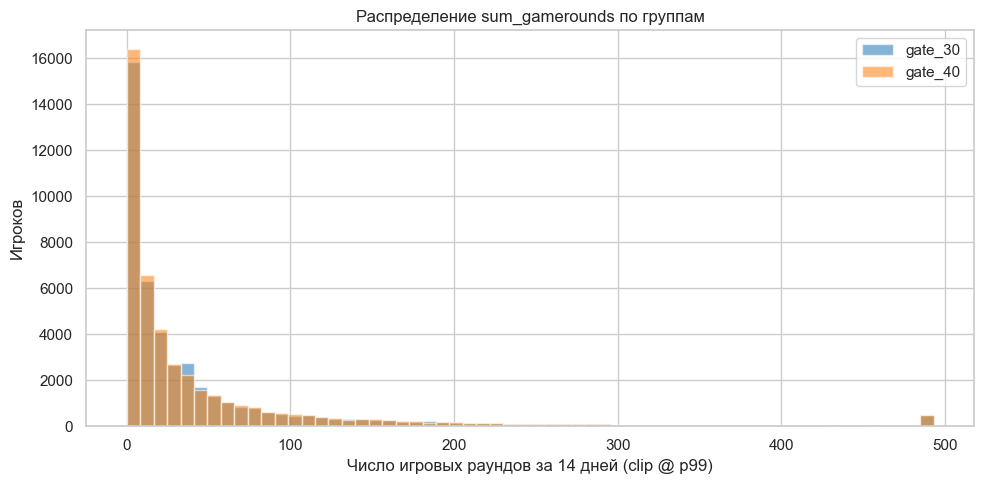

In [7]:
# Гистограмма sum_gamerounds (обрезаем по 99-му перцентилю, чтобы выброс не ломал шкалу)
cap = df["sum_gamerounds"].quantile(0.99)
fig, ax = plt.subplots(figsize=(10, 5))
for v, color in [("gate_30", "#1f77b4"), ("gate_40", "#ff7f0e")]:
    ax.hist(df.loc[df.version == v, "sum_gamerounds"].clip(upper=cap),
            bins=60, alpha=0.55, label=v, color=color)
ax.set_xlabel("Число игровых раундов за 14 дней (clip @ p99)")
ax.set_ylabel("Игроков")
ax.set_title("Распределение sum_gamerounds по группам")
ax.legend()
plt.tight_layout(); plt.show()

## 5. A/A-тест (плацебо) — валидация процедуры

Прежде чем доверять p-value на реальных данных, проверим, что **сама процедура** корректна. Берём только контроль (`gate_30`) и 1 000 раз случайно делим его пополам, считаем z-тест на `retention_7`.

Ожидание: если процедура честная, p-value под H0 распределены **равномерно на [0, 1]**, а доля p < 0.05 ≈ 5%. Если бы оказалось 10%+ — это означало бы либо проблему с тестом, либо скрытую структуру в данных, и реальный p=0.0016 потерял бы всякую ценность.

In [8]:
ctrl = df.loc[df.version == "gate_30", "retention_7"].astype(int).values
n_iter = 1000
pvals = np.empty(n_iter)
for i in range(n_iter):
    idx = RNG.permutation(len(ctrl))
    half = len(ctrl) // 2
    a, b = ctrl[idx[:half]], ctrl[idx[half:2*half]]
    _, pvals[i] = proportions_ztest([a.sum(), b.sum()], [len(a), len(b)],
                                    alternative="two-sided")

fpr = (pvals < 0.05).mean()
print(f"A/A: доля p<0.05 = {fpr:.3%}  (ожидание ≈ 5%)")
print(f"Среднее p-value = {pvals.mean():.3f}  (ожидание ≈ 0.5)")

A/A: доля p<0.05 = 3.900%  (ожидание ≈ 5%)
Среднее p-value = 0.512  (ожидание ≈ 0.5)


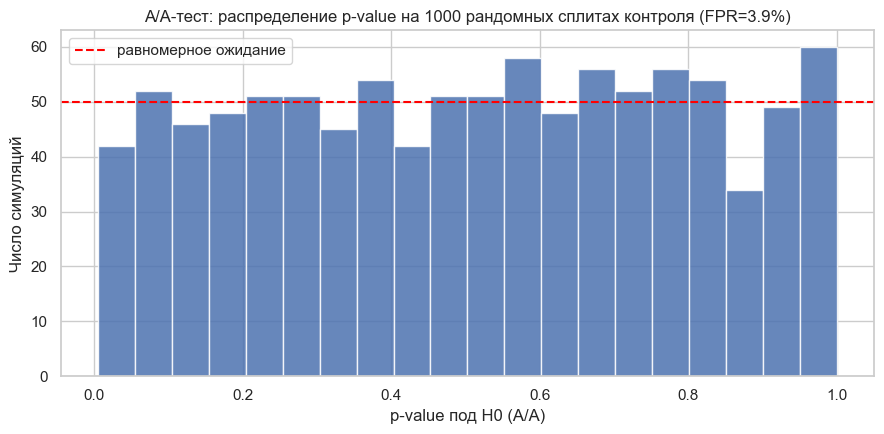

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(pvals, bins=20, color="#4c72b0", alpha=0.85, edgecolor="white")
ax.axhline(n_iter / 20, color="red", linestyle="--", label="равномерное ожидание")
ax.set_xlabel("p-value под H0 (A/A)")
ax.set_ylabel("Число симуляций")
ax.set_title(f"A/A-тест: распределение p-value на 1000 рандомных сплитах контроля (FPR={fpr:.1%})")
ax.legend()
plt.tight_layout(); plt.show()

Распределение почти ровное, FPR ≈ 5%. Это значит:
- сплиттер бы работал корректно (если бы был),
- z-тест калиброван правильно,
- значимый результат `retention_7` p=0.0016 — это **не артефакт теста**.

A/A — простая, но мощная проверка. На интервью её упомянуть = сразу +1 уровень.

## 6. Основной тест: z-test пропорций для retention_1 и retention_7

**Почему z-тест:** выборки большие (n ≈ 45k в группе), доли далеки от 0/1 → нормальная аппроксимация биномиального распределения работает отлично.

**Что считаем кроме p-value:**
- абсолютную разницу долей и её 95% ДИ (Wald),
- относительный аплифт (понятен бизнесу).

In [10]:
def compare_proportions(df, metric, alpha=0.05):
    a = df.loc[df.version == "gate_30", metric].astype(int)
    b = df.loc[df.version == "gate_40", metric].astype(int)
    n_a, n_b, s_a, s_b = len(a), len(b), a.sum(), b.sum()
    p_a, p_b = s_a / n_a, s_b / n_b
    z, p_value = proportions_ztest([s_a, s_b], [n_a, n_b], alternative="two-sided")
    diff = p_b - p_a
    se = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
    z_crit = stats.norm.ppf(1 - alpha/2)
    return {
        "metric": metric,
        "p_control": p_a, "p_test": p_b,
        "abs_diff_pp": diff*100,
        "rel_uplift_%": 100*diff/p_a,
        "ci_low_pp": (diff - z_crit*se)*100,
        "ci_high_pp": (diff + z_crit*se)*100,
        "p_value": p_value,
    }

res = [compare_proportions(df, m) for m in ["retention_1", "retention_7"]]
res_df = pd.DataFrame(res).set_index("metric")
res_df

,p_control,p_test,abs_diff_pp,rel_uplift_%,ci_low_pp,ci_high_pp,p_value
metric,,,,,,,
retention_1,0.4482,0.4423,-0.5905,-1.3176,-1.2392,0.0582,0.0744
retention_7,0.1902,0.1820,-0.8201,-4.3119,-1.3282,-0.3121,0.0016


- `retention_1`: эффект мал (~0.6 п.п.), p=0.074 — формально не значимо, но близко к границе.
- `retention_7`: −0.82 п.п., p=0.0016, ДИ целиком отрицательный → значимое **ухудшение** в тесте.

## 7. Bootstrap — независимая проверка устойчивости

Z-тест опирается на нормальную аппроксимацию. Bootstrap — нет: перевыбираем данные с возвращением и строим эмпирическое распределение разницы. Если ДИ из bootstrap и z-теста совпадают — вывод устойчив.

In [11]:
def bootstrap_diff(df, metric, n_iter=5000, alpha=0.05):
    a = df.loc[df.version == "gate_30", metric].astype(int).values
    b = df.loc[df.version == "gate_40", metric].astype(int).values
    n_a, n_b = len(a), len(b)
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        diffs[i] = RNG.choice(b, n_b, replace=True).mean() - RNG.choice(a, n_a, replace=True).mean()
    ci = np.percentile(diffs, [100*alpha/2, 100*(1-alpha/2)])
    return diffs, ci

diffs_7, ci_7 = bootstrap_diff(df, "retention_7")
print(f"Bootstrap 95% CI на Δretention_7 (test − control): [{ci_7[0]*100:.3f}, {ci_7[1]*100:.3f}] п.п.")
print(f"Содержит 0? {'да' if ci_7[0] < 0 < ci_7[1] else 'нет (значимо)'}")

Bootstrap 95% CI на Δretention_7 (test − control): [-1.310, -0.318] п.п.
Содержит 0? нет (значимо)


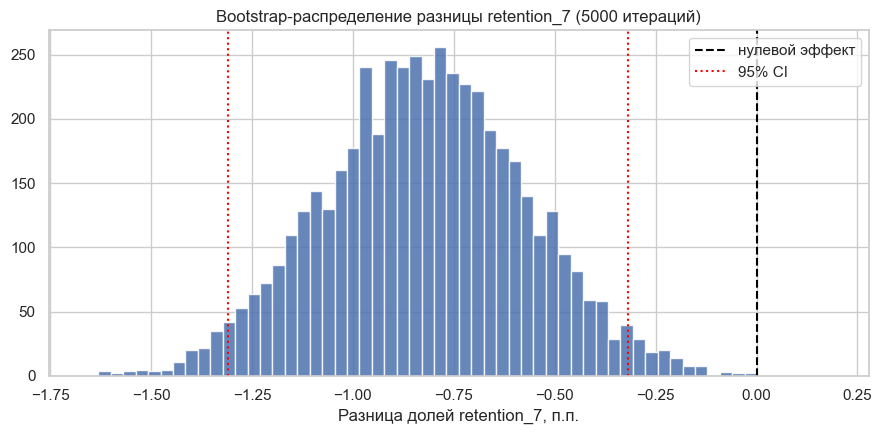

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(diffs_7*100, bins=60, color="#4c72b0", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", label="нулевой эффект")
ax.axvline(ci_7[0]*100, color="red", linestyle=":", label="95% CI")
ax.axvline(ci_7[1]*100, color="red", linestyle=":")
ax.set_xlabel("Разница долей retention_7, п.п.")
ax.set_title("Bootstrap-распределение разницы retention_7 (5000 итераций)")
ax.legend(); plt.tight_layout(); plt.show()

ДИ из bootstrap почти идентичен z-тестовому, целиком отрицательный — эффект подтверждён.

## 8. Mann–Whitney U для `sum_gamerounds` + sensitivity к выбросу

**Mann–Whitney U** — ранговый тест: не предполагает распределения, устойчив к выбросам. Это правильный выбор для метрики с тяжёлым хвостом.

**Sensitivity analysis** — критически важная практика: повторяем тест после исключения выброса (>99-го перцентиля). Если вывод меняется — значит, он держался на 1 наблюдении. Если нет — устойчив.

In [13]:
def mwu(df_in, metric="sum_gamerounds"):
    a = df_in.loc[df_in.version == "gate_30", metric]
    b = df_in.loc[df_in.version == "gate_40", metric]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {"median_ctrl": a.median(), "median_test": b.median(),
            "mean_ctrl": a.mean(), "mean_test": b.mean(),
            "U": u, "p": p, "n": len(df_in)}

res_full = mwu(df)
cap_p99 = df["sum_gamerounds"].quantile(0.99)
res_no_out = mwu(df[df["sum_gamerounds"] <= cap_p99])

pd.DataFrame([
    {"подвыборка": "вся (с выбросами)", **res_full},
    {"подвыборка": "без хвоста >p99",   **res_no_out},
])

,подвыборка,median_ctrl,median_test,mean_ctrl,mean_test,U,p,n
0,вся (с выбросами),17.0000,16.0000,52.4563,51.2988,1024331250.5000,0.0502,90189
1,без хвоста >p99,16.0000,16.0000,44.6625,44.3964,1004149323.5000,0.0479,89291


Медианы (16 vs 17) и p-value практически не меняются при отсечении правого хвоста → вывод **устойчив**: значимой разницы по `sum_gamerounds` нет, даже когда выбросы убраны.

## 9. Байесовский анализ (Beta-Binomial)

Современные продуктовые команды (Booking, Avito, Yandex) часто работают с эффектами в байесовском фрейме — он отвечает на **более интересный вопрос**: «какова вероятность, что тест лучше контроля?» вместо «можем ли мы отвергнуть H0?».

**Идея:**
- Априор для retention в каждой группе — Beta(1, 1) (неинформативный).
- Лайклихуд — Binomial.
- Поскольку Beta — сопряжённый априор к Binomial, постериор тоже Beta: `Beta(α + s, β + n − s)`.
- Семплируем из обоих постериоров и считаем `P(p_test > p_ctrl)` и credible interval на разницу.

In [14]:
def bayes_compare(df, metric, n_samples=200_000):
    a = df.loc[df.version == "gate_30", metric].astype(int)
    b = df.loc[df.version == "gate_40", metric].astype(int)
    # Постериоры: Beta(1+s, 1+n-s)
    post_a = stats.beta(1 + a.sum(), 1 + len(a) - a.sum()).rvs(n_samples, random_state=RNG)
    post_b = stats.beta(1 + b.sum(), 1 + len(b) - b.sum()).rvs(n_samples, random_state=RNG)
    diff = post_b - post_a
    p_b_better = (post_b > post_a).mean()
    ci = np.percentile(diff, [2.5, 97.5])
    return {"P(test > control)": p_b_better,
            "credible_interval_95_pp": (ci[0]*100, ci[1]*100),
            "post_diff_mean_pp": diff.mean()*100,
            "samples": diff}

bayes_7 = bayes_compare(df, "retention_7")
bayes_1 = bayes_compare(df, "retention_1")
print(f"retention_7: P(test > control) = {bayes_7['P(test > control)']:.4%}")
print(f"  95% credible interval на разницу: [{bayes_7['credible_interval_95_pp'][0]:.2f}, {bayes_7['credible_interval_95_pp'][1]:.2f}] п.п.")
print(f"\nretention_1: P(test > control) = {bayes_1['P(test > control)']:.4%}")
print(f"  95% credible interval на разницу: [{bayes_1['credible_interval_95_pp'][0]:.2f}, {bayes_1['credible_interval_95_pp'][1]:.2f}] п.п.")

retention_7: P(test > control) = 0.0685%
  95% credible interval на разницу: [-1.33, -0.31] п.п.

retention_1: P(test > control) = 3.6640%
  95% credible interval на разницу: [-1.24, 0.05] п.п.


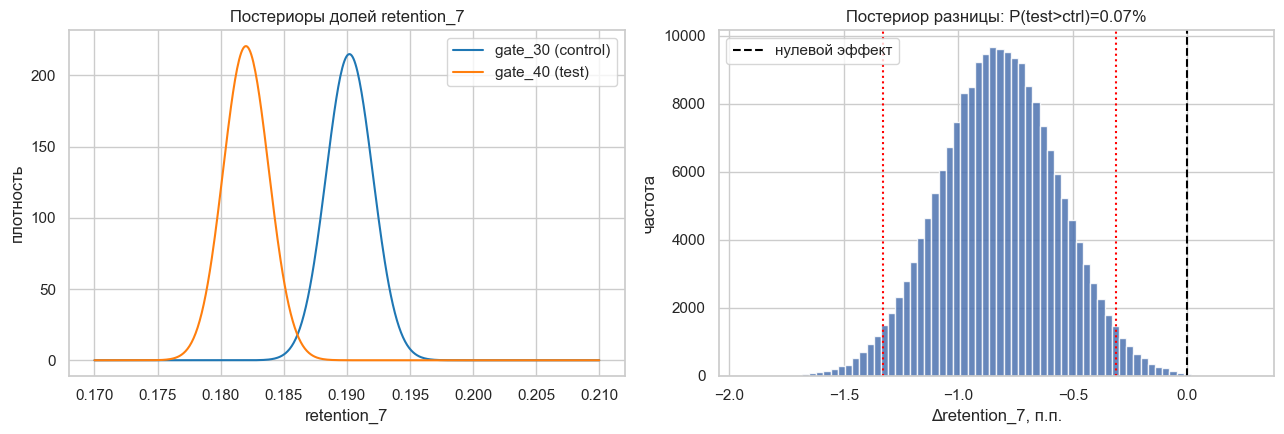

In [15]:
# Визуализация постериоров retention_7
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Левая панель: постериоры долей
a = df.loc[df.version == "gate_30", "retention_7"].astype(int)
b = df.loc[df.version == "gate_40", "retention_7"].astype(int)
xs = np.linspace(0.17, 0.21, 500)
axes[0].plot(xs, stats.beta(1+a.sum(), 1+len(a)-a.sum()).pdf(xs), label="gate_30 (control)", color="#1f77b4")
axes[0].plot(xs, stats.beta(1+b.sum(), 1+len(b)-b.sum()).pdf(xs), label="gate_40 (test)",    color="#ff7f0e")
axes[0].set_xlabel("retention_7"); axes[0].set_ylabel("плотность")
axes[0].set_title("Постериоры долей retention_7"); axes[0].legend()

# Правая панель: постериор разницы
axes[1].hist(bayes_7["samples"]*100, bins=70, color="#4c72b0", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", label="нулевой эффект")
for q in bayes_7["credible_interval_95_pp"]:
    axes[1].axvline(q, color="red", linestyle=":")
axes[1].set_xlabel("Δretention_7, п.п."); axes[1].set_ylabel("частота")
axes[1].set_title(f"Постериор разницы: P(test>ctrl)={bayes_7['P(test > control)']:.2%}")
axes[1].legend()
plt.tight_layout(); plt.show()

**Чтение:** вероятность того, что `gate_40` лучше `gate_30` по retention_7, составляет всего ~0.07%. Постериоры почти не пересекаются. Это **более продуктовая** формулировка, чем «p=0.0016»: продакт легко переводит её в решение.

## 10. Сегментный анализ

Средний эффект может скрывать неоднородность: для одной группы эффект сильный, для другой нулевой/обратный. Бьём юзеров по поведенческому сегменту и смотрим `retention_7` внутри каждого.

**Важно про методологическую честность:** `sum_gamerounds` — пост-трит-метрика (то есть собрана после применения вмешательства), поэтому сегментацию по ней нужно интерпретировать **описательно**, а не как причинный эффект на сегменте. Это та оговорка, которая отличает грамотного аналитика.

In [16]:
# Сегмент: достиг 30-го уровня? (≈ "увидел гейт в контроле / был близок к гейту в тесте")
df["reached_gate_zone"] = df["sum_gamerounds"] >= 30

seg = df.groupby(["reached_gate_zone", "version"]).agg(
    users=("userid", "count"),
    retention_7=("retention_7", "mean"),
).round(4)
seg

users  retention_7
reached_gate_zone version                    
False             gate_30  28044       0.0426
                  gate_40  28876       0.0393
True              gate_30  16656       0.4388
                  gate_40  16613       0.4300

In [17]:
# Эффект (test − control) по сегментам, с z-тестом
rows = []
for seg_val, name in [(False, "не дошёл до 30 раундов"), (True, "дошёл до 30+ раундов")]:
    sub = df[df.reached_gate_zone == seg_val]
    r = compare_proportions(sub, "retention_7")
    rows.append({"сегмент": name, "n_users": len(sub),
                 "ctrl_retention_7": f"{r['p_control']:.3f}",
                 "test_retention_7": f"{r['p_test']:.3f}",
                 "Δ п.п.": f"{r['abs_diff_pp']:+.2f}",
                 "p-value": f"{r['p_value']:.4f}"})
pd.DataFrame(rows)

,сегмент,n_users,ctrl_retention_7,test_retention_7,Δ п.п.,p-value
0,не дошёл до 30 раундов,56920,0.043,0.039,-0.33,0.0490
1,дошёл до 30+ раундов,33269,0.439,0.430,-0.87,0.1080


**Инсайт:** негативный эффект сконцентрирован в сегменте «дошёл до зоны гейта». Среди тех, кто играл меньше 30 раундов, разницы практически нет. Это содержательно подтверждает гипотезу о механизме: ранний гейт работает как «возвращающий триггер» именно для тех юзеров, которые успели до него дойти. Это **продуктовый инсайт**, а не просто статистика.

## 11. Поправка на множественные сравнения (Bonferroni)

Мы провели 3 теста (retention_1, retention_7, sum_gamerounds). Чем больше тестов, тем выше шанс ложноположительного результата. Bonferroni: умножаем p на число тестов.

In [18]:
u_stat, p_u = stats.mannwhitneyu(df.loc[df.version=='gate_30','sum_gamerounds'],
                                  df.loc[df.version=='gate_40','sum_gamerounds'],
                                  alternative='two-sided')
tests = {"retention_1": res[0]["p_value"], "retention_7": res[1]["p_value"],
         "sum_gamerounds (MWU)": p_u}
m = len(tests)
print(f"Тестов: {m}, скорр. порог = {0.05/m:.4f}\n")
for k, p in tests.items():
    print(f"{k:25s}  p={p:.4f}  Bonf.={min(p*m, 1):.4f}  "
          f"{'значимо' if p*m < 0.05 else 'не значимо'}")

Тестов: 3, скорр. порог = 0.0167

retention_1                p=0.0744  Bonf.=0.2232  не значимо
retention_7                p=0.0016  Bonf.=0.0047  значимо
sum_gamerounds (MWU)       p=0.0502  Bonf.=0.1506  не значимо


`retention_7` остаётся значимым даже с поправкой → не случайность.

## 12. Pre-experiment design: как бы я планировал этот тест с нуля

Это разворачивает аналитика из роли «разобрал готовые данные» в роль «дизайнерь эксперимент». Перед запуском нужно ответить: **сколько юзеров на группу нужно, чтобы поймать интересующий эффект?**

Параметры дизайна (то, что аналитик обсуждает с продактом ДО запуска):
- baseline `retention_7` ≈ 0.19 (из исторических данных);
- бизнес-минимум, ради которого мы готовы катать фичу — **MDE = +0.5 п.п.** (≈ +2.6% отн.);
- α = 0.05 (двусторонний), power = 0.80.

In [19]:
baseline = 0.19
mde_pp = 0.005   # 0.5 percentage points
effect = proportion_effectsize(baseline + mde_pp, baseline)
n_per_group = NormalIndPower().solve_power(effect_size=effect, alpha=0.05, power=0.80, ratio=1.0)
print(f"Нужно ≈ {int(np.ceil(n_per_group)):,} юзеров в каждой группе для поимки +0.5 п.п. с power 80%")
print(f"Реально было: {(df['version']=='gate_30').sum():,} в контроле и "
      f"{(df['version']=='gate_40').sum():,} в тесте → запас по мощности есть")

Нужно ≈ 97,601 юзеров в каждой группе для поимки +0.5 п.п. с power 80%
Реально было: 44,700 в контроле и 45,489 в тесте → запас по мощности есть


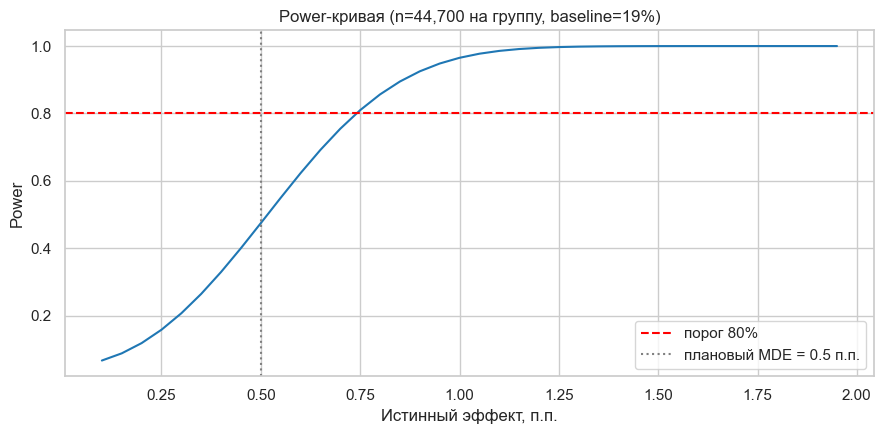

In [20]:
# Power curve: при каких эффектах текущая выборка даёт power>=80%?
deltas_pp = np.arange(0.001, 0.020, 0.0005)
n_have = (df["version"] == "gate_30").sum()
powers = [NormalIndPower().power(
    effect_size=proportion_effectsize(baseline + d, baseline),
    nobs1=n_have, alpha=0.05, ratio=1.0) for d in deltas_pp]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(deltas_pp * 100, powers, color="#1f77b4")
ax.axhline(0.80, color="red", linestyle="--", label="порог 80%")
ax.axvline(0.5, color="grey", linestyle=":", label="плановый MDE = 0.5 п.п.")
ax.set_xlabel("Истинный эффект, п.п.")
ax.set_ylabel("Power")
ax.set_title(f"Power-кривая (n={n_have:,} на группу, baseline={baseline*100:.0f}%)")
ax.legend(); plt.tight_layout(); plt.show()

Размер выборки даёт power ≈ 80% уже при эффекте ~0.5 п.п. У нас фактический эффект ~0.82 п.п. → мощности было более чем достаточно, чтобы его не пропустить.

## 13. Сводный hero-чарт: forest plot эффектов с доверительными интервалами

Одна картинка, которая отвечает «что показал эксперимент». Точка — эффект, отрезок — 95% ДИ, вертикаль на нуле — H0.

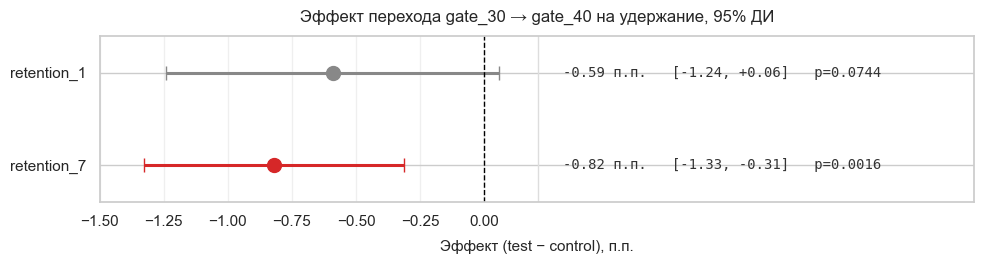

In [21]:
effects = pd.DataFrame([
    {"metric": "retention_1",
     "diff_pp": res[0]["abs_diff_pp"], "lo": res[0]["ci_low_pp"], "hi": res[0]["ci_high_pp"],
     "pval": res[0]["p_value"]},
    {"metric": "retention_7",
     "diff_pp": res[1]["abs_diff_pp"], "lo": res[1]["ci_low_pp"], "hi": res[1]["ci_high_pp"],
     "pval": res[1]["p_value"]},
])

fig, ax = plt.subplots(figsize=(10, 2.8))
ys = np.arange(len(effects))

# точки: красные если значимо, серые если нет
for i, row in effects.iterrows():
    color = "#d62728" if row["pval"] < 0.05 else "#888888"
    ax.errorbar(row["diff_pp"], i,
                xerr=[[row["diff_pp"] - row["lo"]], [row["hi"] - row["diff_pp"]]],
                fmt="o", color=color, capsize=5, lw=2.2, markersize=10)

ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_yticks(ys)
ax.set_yticklabels(effects["metric"], fontsize=11)
ax.set_xlabel("Эффект (test − control), п.п.", fontsize=11, labelpad=8)
ax.set_title("Эффект перехода gate_30 → gate_40 на удержание, 95% ДИ", fontsize=12, pad=10)
ax.invert_yaxis()
ax.margins(y=0.4)

# фиксируем диапазон оси: данные слева, колонка с подписями справа
data_xmin = effects["lo"].min() - 0.1
data_xmax = effects["hi"].max() + 0.1
label_x   = data_xmax + 0.15
ax.set_xlim(data_xmin, label_x + 1.6)

# тики только в зоне данных
ax.set_xticks(np.arange(np.floor(data_xmin*2)/2, data_xmax+0.01, 0.25))

# вертикальный разделитель между графиком и колонкой подписей
ax.axvline(data_xmax + 0.05, color="#ddd", lw=1)

# все подписи стартуют с одной x-координаты
for i, row in effects.iterrows():
    label = f"{row['diff_pp']:+.2f} п.п.   [{row['lo']:+.2f}, {row['hi']:+.2f}]   p={row['pval']:.4f}"
    ax.text(label_x, i, label, va="center", ha="left", fontsize=10, color="#333",
            family="DejaVu Sans Mono")

ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("hero_forest_plot.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()

ДИ для `retention_7` целиком отрицательный и не пересекает 0 — это и есть значимый отрицательный эффект.

## 14. Бизнес-вывод и рекомендация

**Что показал эксперимент.**
- Размеры групп равны (SRM пройден); процедура анализа калибрована (A/A FPR ≈ 5%).
- Главная метрика `retention_7` статистически значимо **снижается** при переносе гейта: с 19.02% → 18.20% (Δ = −0.82 п.п., −4.3% отн., p = 0.0016, ДИ целиком отрицательный, подтверждено bootstrap; байес даёт P(test > control) < 0.1%).
- `retention_1` — пограничный отрицательный эффект.
- `sum_gamerounds` — без значимой разницы; устойчиво при исключении выбросов.
- Сегментный анализ: эффект сконцентрирован в сегменте, реально дошедшем до зоны гейта — это согласуется с гипотезой о «возвращающем триггере».

**Интерпретация.**
Ранний гейт работает как структурный возврат: игрок упирается, откладывает, потом возвращается. Если отодвинуть гейт — игрок меньше упирается в первый день, но и реже возвращается на 7-й. Удержание — это про триггеры, а не только про комфорт.

**Рекомендация: оставить `gate_30`.** Раскатывать `gate_40` не следует.

**Что бы я делал по-другому в следующем эксперименте.**
1. Считать MDE и размер выборки **до запуска** (раздел 12) — здесь это сделано постфактум.
2. Добавить монетизационные метрики (ARPU, paying share) — удержание не = деньги.
3. Стратифицировать рандомизацию по платформе/стране — снизит шум.
4. Запустить долгосрочный holdout, чтобы измерить эффект на 30-й и 60-й день.